# 01 - Modelado Avanzado: Resolviendo Desbalance y Extrayendo Insights

Este notebook consolida la limpieza del baseline, aplica **pesos a las clases** para solucionar el bajo Recall de los desnutridos, y extrae la **Importancia de Variables**.


In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# 1. Cargar datos
master = pd.read_parquet('../../data/interim/master_merged.parquet')
columnas_iniciales = master.shape[1]

# 2. Filtrar Nulos del Target y Crear Binario
master = master.dropna(subset=['HC70']).copy()
master['TARGET_DESNUTRICION'] = (master['HC70'] < -2.0).astype(int)

# 3. La Guillotina de Nulos (>60% nulos fuera)
master = master.dropna(thresh=len(master)*0.40, axis=1)

# 4. Separar Metadatos temporales y geográficos
metadata_cols = ['UBIGEO', 'LONGITUDX', 'LATITUDY', 'year', 'HHID']
metadata_df = master[metadata_cols].copy()

# 5. Listas de Eliminación (Leakage, Colinealidad, Redundancia)
leakage_cols = [
    'HC0', 'HVIDX', 'HV112', 'HV001', 'HV002', 'HV002A', 'NCONGLOME', 'CODCCPP', 'NOMCCPP', 'ID1',
    'HC2', 'HC3', 'HC4', 'HC5', 'HC6', 'HC7', 'HC8', 'HC9', 'HC10', 'HC11', 'HC12', 'HC13', 
    'HC15', 'HC16', 'HC19', 'HC30', 'HC31', 'HC32', 'HC33', 'HC71', 'HC72', 'HC73', 'HC55', 'HC70',
    'HV004', 'HV005', 'hv005', 'HV008', 'HV015', 'HV021', 'HV022', 
    'HV024', 'SHREGION', 'SHPROVIN', 'SHDISTRI', 'SHSEMES', 
    'HV120', 'HV010', 'HV035', 'HC64', 'HV114', 'HC51', 'HC60', 
    'HV218', 'HV117'
]

colineales_cols = [
    # --- NUEVAS VARIABLES ELIMINADAS POR FEATURE SELECTION (P-Values, Colinealidad, XGBoost) ---
    'HV109', 'HV013', 'HV105', 'HV108', # Clones (Correlación > 0.85)
    'HV103', 'HV122', 'HV225', 'HV237C', 'HV237E', 'HV243C', # P-Value > 0.05 (Ruido estadístico)
    'HV128', 'HV237X', # Importancia Cero comprobada por XGBoost
    # ---------------------------------------------------------------------------------------
    'HC53', 'HC57', 'HC61', 'HV106', 'HV109', 'HV270', 'HV009', 'HV013', 'HV104', 'HV105', 'SH71',
    'QH227A', 'QH227B', 'HV121', 'HV122', 'HV124', 'HV125', 'HV126', 'HV128'
]

redundant_cols = []
for col in master.columns:
    if re.search(r'HV20[6-9]|HV21[0-2]|HV221|HV243A', col, re.IGNORECASE) or re.search(r'SH51[A-Z]|SH61[A-Z]|SH76[A-Z]', col, re.IGNORECASE):
        redundant_cols.append(col)

# Ejecutar Guillotina Total
todas_a_eliminar = leakage_cols + metadata_cols + colineales_cols + redundant_cols
cols_to_drop = [c for c in todas_a_eliminar if c in master.columns]
master = master.drop(columns=cols_to_drop)

print(f"Dataset limpio. Filas: {len(master)} | Columnas sobrevivientes: {master.shape[1]}")


Dataset limpio. Filas: 285284 | Columnas sobrevivientes: 49


In [2]:
# 6. Separar Features y Target
features = master.drop(columns=['TARGET_DESNUTRICION'])
target = master['TARGET_DESNUTRICION']

# 7. Tipado Nativo para Árboles Modernos
for col in features.columns:
    if not pd.api.types.is_numeric_dtype(features[col]):
        # Rellenar vacíos explícitamente para CatBoost
        features[col] = features[col].fillna('Desconocido')
        features[col] = features[col].astype(str).astype('category')


In [3]:
import sys
import os
import unicodedata

sys.path.append(os.path.abspath('../../')) 
from mnp.configs.column_labels import LABELS

# 8. Renombrar y Aplanar Columnas
features = features.rename(columns=LABELS)

clean_cols = []
for col in features.columns:
    col_str = unicodedata.normalize('NFKD', str(col)).encode('ASCII', 'ignore').decode('utf-8')
    col_str = re.sub(r'[^a-zA-Z0-9]+', '_', col_str).strip('_')
    clean_cols.append(col_str)
features.columns = clean_cols

print("Columnas renombradas y aplanadas. Ejemplo:")
print(features.columns[:5].tolist())


2026-06-16 12:18:58.891 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /Users/abelguevarah/Desktop/invs/malnutrition-research


Columnas renombradas y aplanadas. Ejemplo:
['HC1_Edad_en_meses', 'HC27_Sexo', 'HC56_Nivel_de_hemoglobina_ajustado_por_altitud', 'HC62_Ano_mas_alto_de_educacion_de_la_madre', 'HC63_Intervalo_de_nacimientos_anteriores_al_nino']


In [4]:
# 9. División Temporal Train/Test
train_mask = metadata_df['year'] <= 2018
test_mask = metadata_df['year'] > 2018

X_train = features[train_mask]
y_train = target[train_mask]
X_test = features[test_mask]
y_test = target[test_mask]

print(f"Train (<=2018): {X_train.shape}")
print(f"Test (>2018): {X_test.shape}")


Train (<=2018): (165234, 48)
Test (>2018): (120050, 48)


Aplicando Undersampling solo a los datos de Train...
Train Original (Desbalanceado): (165234, 48)
Train Nuevo (Balanceado 50/50): (61294, 48)


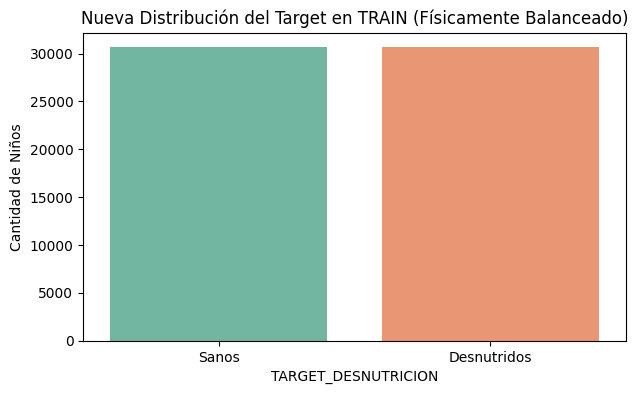

In [5]:
# 10. BALANCEO FÍSICO DE DATOS (Undersampling)
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import seaborn as sns

print("Aplicando Undersampling solo a los datos de Train...")
# El Undersampler reducirá la clase mayoritaria (Sanos) descartando datos aleatorios 
# hasta igualar a la clase minoritaria (Desnutridos).
rus = RandomUnderSampler(random_state=42)

X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

print(f"Train Original (Desbalanceado): {X_train.shape}")
print(f"Train Nuevo (Balanceado 50/50): {X_train_resampled.shape}")

# Visualizamos el nuevo balance
plt.figure(figsize=(7, 4))
ax = sns.countplot(x=y_train_resampled, palette='Set2')
plt.title('Nueva Distribución del Target en TRAIN (Físicamente Balanceado)')
plt.xticks([0, 1], ['Sanos', 'Desnutridos'])
plt.ylabel('Cantidad de Niños')
plt.show()

# OJO: Los datos de TEST (X_test, y_test) NO se tocan. Se mantienen desbalanceados 
# porque representan el mundo real que el modelo debe predecir.


In [6]:
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import time

# 11. ENTRENAMIENTO SIN PESOS ALGORÍTMICOS
# Como los datos ya están físicamente 50/50, los modelos pueden entrenar de forma pura.

cat_features = X_train_resampled.select_dtypes(include=['category']).columns.tolist()

models = {
    'XGBoost': xgb.XGBClassifier(
        random_state=42, 
        eval_metric='logloss', 
        enable_categorical=True
    ),
    'LightGBM': lgb.LGBMClassifier(
        random_state=42, 
        verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        random_state=42, 
        verbose=0
    )
}

trained_models = {}

for name, model in models.items():
    print(f"Entrenando {name} con datos 50/50...")
    start_time = time.time()
    
    if name == 'CatBoost':
        model.fit(X_train_resampled, y_train_resampled, cat_features=cat_features)
    else:
        model.fit(X_train_resampled, y_train_resampled)
        
    trained_models[name] = model
    print(f"[{name}] Completado en {time.time() - start_time:.2f} segundos.\n")


Entrenando XGBoost con datos 50/50...
[XGBoost] Completado en 1.03 segundos.

Entrenando LightGBM con datos 50/50...
[LightGBM] Completado en 0.51 segundos.

Entrenando CatBoost con datos 50/50...
[CatBoost] Completado en 70.32 segundos.



--- MÉTRICAS CON CLASES BALANCEADAS ---

==================== XGBoost ====================
➜ AUC-ROC Score: 0.7446
                 precision    recall  f1-score   support

      Sanos (0)       0.92      0.81      0.86    104856
Desnutridos (1)       0.29      0.53      0.37     15194

       accuracy                           0.77    120050
      macro avg       0.60      0.67      0.62    120050
   weighted avg       0.84      0.77      0.80    120050


==================== LightGBM ====================
➜ AUC-ROC Score: 0.7553
                 precision    recall  f1-score   support

      Sanos (0)       0.92      0.82      0.87    104856
Desnutridos (1)       0.29      0.53      0.38     15194

       accuracy                           0.78    120050
      macro avg       0.61      0.67      0.62    120050
   weighted avg       0.84      0.78      0.80    120050


==================== CatBoost ====================
➜ AUC-ROC Score: 0.7569
                 precision    recall  f1-sc

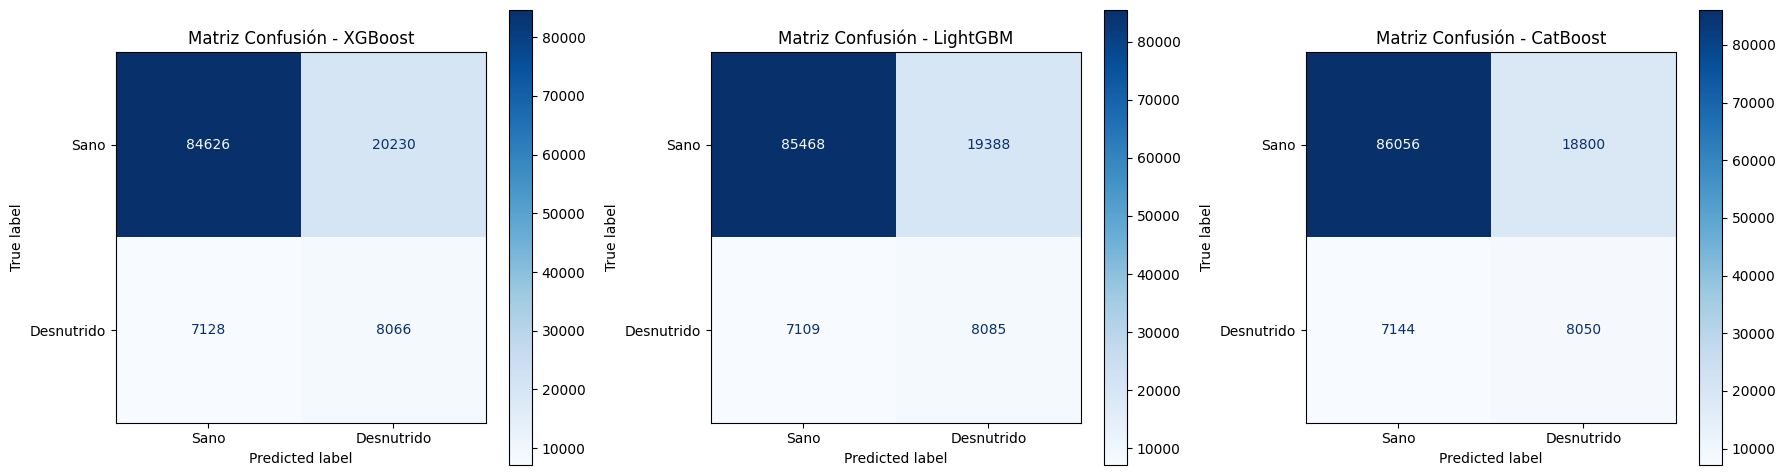

In [7]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- MÉTRICAS CON CLASES BALANCEADAS ---")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(trained_models.items()):
    print(f"\n==================== {name} ====================")
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_proba)
    print(f"➜ AUC-ROC Score: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Sanos (0)', 'Desnutridos (1)']))
    
    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano', 'Desnutrido'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f"Matriz Confusión - {name}")

plt.tight_layout()
plt.show()


Extrayendo Importancia de Variables del Mejor Modelo (CatBoost)


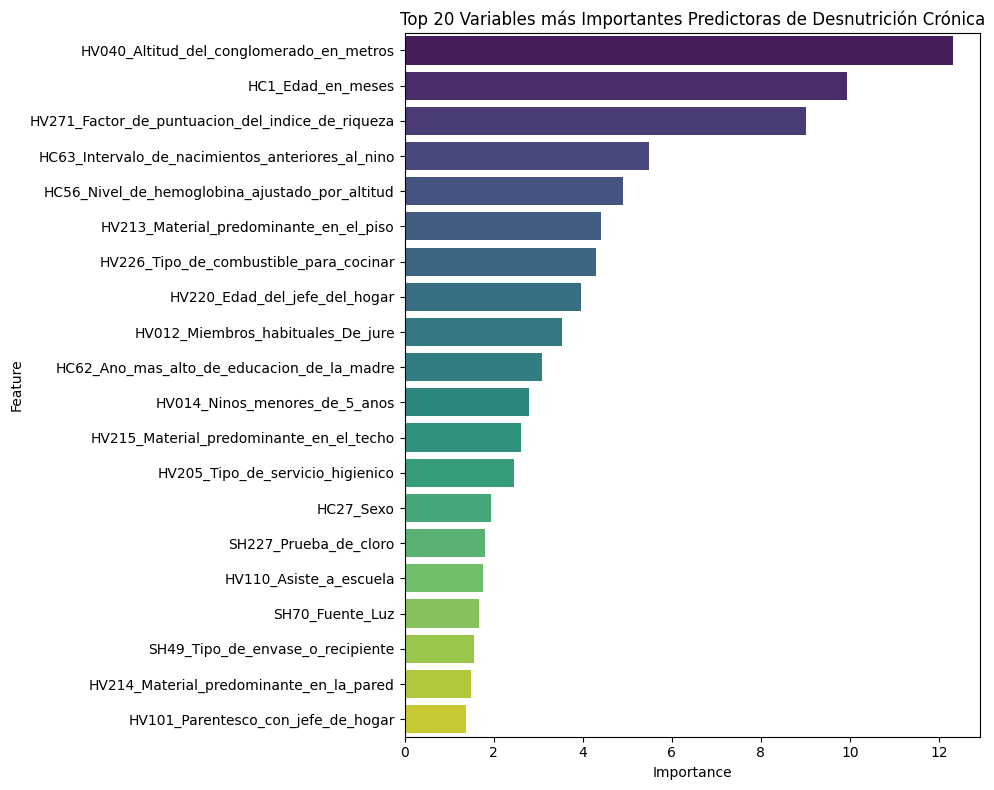

In [9]:
# 12. IMPORTANCIA DE VARIABLES (Insights Médicos/Sociales)
import seaborn as sns

print("Extrayendo Importancia de Variables del Mejor Modelo (CatBoost)")
cb_model = trained_models['CatBoost']

importances = cb_model.get_feature_importance()
feat_imp_df = pd.DataFrame({
    'Feature': X_train_resampled.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Top 20 Variables más Importantes Predictoras de Desnutrición Crónica')
plt.tight_layout()
plt.show()
